<a href="https://colab.research.google.com/github/Rellendula26/CIS5450/blob/main/hw4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --upgrade "git+https://github.com/RyanMarcus/penngrader2.git@8a34a2c"

  Cloning https://github.com/RyanMarcus/penngrader2.git (to revision 8a34a2c) to /tmp/pip-req-build-p13yw5yi
  Running command git clone --filter=blob:none --quiet https://github.com/RyanMarcus/penngrader2.git /tmp/pip-req-build-p13yw5yi
  Running command git checkout -q 8a34a2c
  Resolved https://github.com/RyanMarcus/penngrader2.git to commit 8a34a2c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


# Setup

Change the `penngrader2.login` call below to your student ID. Do not change anything else in the below cell.

In [ ]:
import penngrader2
import numpy as np

penngrader2.configure("https://pg2.rmarcus.info/", api_key="bxP7tLb8S7/KGbZaQrJxJNYEzYymrvNW")
penngrader2.login(99999999)


# Part 1: Alzheimer's Prediction Dataset

We're going to test various machine learning models to detect dementia induced by Alzheimer's. Our models will take brain MRIs as input, and predict the level of dementia.

We'll begin by downloading, organizing, and exploring our data. While we do, we'll learn about [Apache Parquet](https://parquet.apache.org/) and [pyarrow](https://pypi.org/project/pyarrow/), a set of tools for working with large datasets.

## 1.1: Download and view image data (5 points)

First, we download the dataset from the web:

In [ ]:
!apt install zstd
!wget -nc https://upenn.ferric.systems/cis5450/alzheimers.tar.zst
!tar --zstd -xvf alzheimers.tar.zst

Streaming output truncated to the last 5000 lines.
alzheimers/ModerateDemented/39297e13-087d-4e00-8971-2ac28482492b.jpg
alzheimers/ModerateDemented/a1afa6c5-63fb-4286-aaeb-6e0ca0b637b5.jpg
alzheimers/ModerateDemented/fbb15461-4e6e-454a-8151-e39c4e7b99f1.jpg
alzheimers/ModerateDemented/d777c58e-5354-4c15-8f6a-b13740071fcc.jpg
alzheimers/ModerateDemented/b13fcce4-59c4-4798-8e7f-b84ec04d44f6.jpg
alzheimers/ModerateDemented/fbbd29ae-ad95-48f3-b537-4d4a761cbe3d.jpg
alzheimers/ModerateDemented/1358cc3e-9b91-4b71-bce0-4abd5122dcf1.jpg
alzheimers/ModerateDemented/2f2de7e8-2411-4177-8fcc-e61ae104446e.jpg
alzheimers/ModerateDemented/9634d655-970a-413d-b2c3-91297b38d018.jpg
alzheimers/ModerateDemented/8dcf0a87-febf-45e4-9371-06c8fe90cd52.jpg
alzheimers/ModerateDemented/2d72437e-7fa3-49f2-ab6d-17edd45e015d.jpg
alzheimers/ModerateDemented/6323d052-e735-45ae-b1d6-df465a833850.jpg
alzheimers/ModerateDemented/67490f2a-22a6-4329-a96d-a660bff16e7b.jpg
alzheimers/ModerateDemented/e9824f10-c900-4149-a360-

Each file is a JPG image stored in `/content/alzheimers/`. Images are under one of four subfolders:

* `NonDemented`: no signs of dementia
* `VeryMildDemented`: early signs of dementia
* `MildDemented`: signs of dementia
* `ModerateDemented`: signs of strong dementia

As a first step, let's look at a few examples from each folder. Using `matplotlib`, create a photo array with 4 columns (one for each class) and three rows (for each sample image), displaying 12 sample images. Label each image with it's class. Make sure to remove the axes. Save the image as `panel.jpg`.

You can read and plot image data from a JPG like this:

```
data = Image.open("/path/to/image.jpg")
plt.imshow(data, cmap="gray")
```

In [ ]:
from matplotlib import pyplot as plt
import os
import random
from PIL import Image

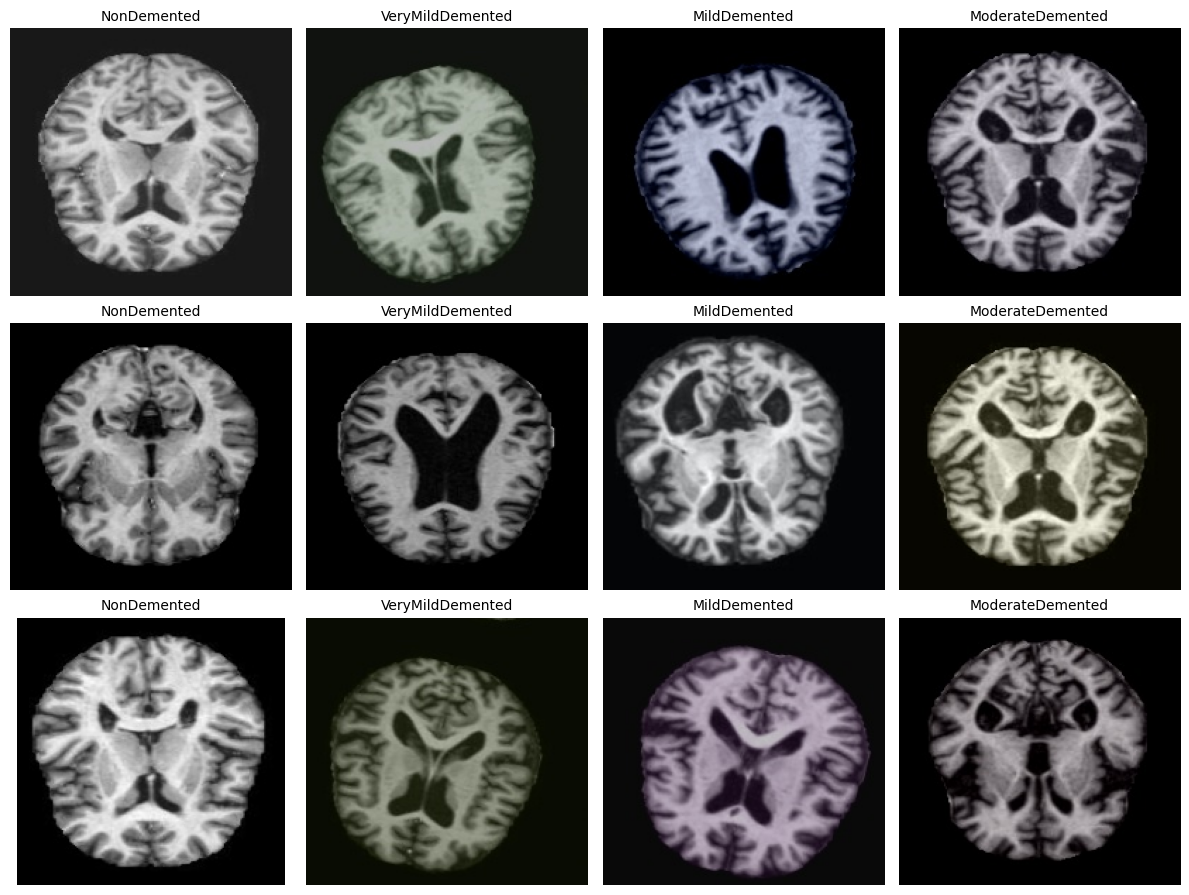

In [ ]:
base_dir = "/content/alzheimers/"

classes = [
   "NonDemented",
   "VeryMildDemented",
   "MildDemented",
   "ModerateDemented"
]

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for col, class_name in enumerate(classes):
  class_path = os.path.join(base_dir, class_name)

  image_files = [f for f in os.listdir(class_path) if f.lower().endswith(".jpg")]

  sample_images = random.sample(image_files, 3)

  for row in range(3):
    img_path = os.path.join(class_path, sample_images[row])
    data = Image.open(img_path)

    axes[row, col].imshow(data, cmap="gray")
    axes[row, col].set_title(class_name, fontsize=10)
    axes[row, col].axis("off")

plt.tight_layout()
plt.savefig("panel.jpg", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import base64
with open("panel.jpg", "rb") as f:
  imgdata = base64.b64encode(f.read()).decode("utf-8")
penngrader2.submit("hw4", "problem1_1", imgdata)

[queued] Queued for grading (position 1)
[started] Grading started
[progress] Prepared grading assistant call
[progress] Grading assitant response is parsed
[succeeded] Grading completed
✅ Correct. Score: 5/5. 



## 1.2: Creating a Parquet file

Currently, our data is stored as individual image files in directories with our class labels. This is fine, but is not very consistent. It is easy to lose a file, or perhaps even an entire class, from the dataset.

Next, we'll build a [Parquet](https://parquet.apache.org) file containing all of our data. Parquet is a columnar format, meaning each column is stored independently. This means we can quickly access arbitrary slices of the data.

Storing images in a Parquet file might seem unusual. While Parquet was mostly designed for tabular data, for small image files (like ours), creating a Parquet file allows us to store and transmit a single file easily. For datasets with significantly larger images, it might make more sense to include a URL to the image in the Parquet file instead of the image itself.

We'll create a Parquet file naned `mri.parquet` with four columns:

* `img_path`, a string column containing the original image path in our dataset, such as `alzheimers/MildDemented/00046ff7-0fae-4796-9a2b-2df47095bfe6.jpg`
* `img_class`, a string column containing the image's class (e.g., `MildDemented`).
* `img_class_numeric`, an 8-bit unsigned integer column reprsenting the class (0 for `NonDemented`, 3 for `ModerateDemented`).
* `img_data`, a binary column containing the raw image data.

You can read image data like this:

```python
with open("path/to/image.jpg", "rb") as f:
  img_data = f.read()
```

It is important that we do not load every single image into memory before dumping them into a Parquet file. While this dataset could potentially fit in our Colab machine's memory, we do not want to make that assumption. Therefore, we want to read a small batch of images, write them to the Parquet file, then go to the next batch. We'll use a batch size of 64.

You can write a Parquet file incrementally like this:

```python
import pyarrow.parquet as pq
with pq.ParquetWriter('mri.parquet', schema) as writer:
  writer.write(table)
```

You'll need to lookup how to construct a PyArrow `table`.


In [ ]:
from pathlib import Path
import pyarrow as pa
import pyarrow.parquet as pq

base_dir = Path("/content/alzheimers")
output_file = "mri.parquet"
batch_size = 64

class_to_num = {
    "NonDemented": 0,
    "VeryMildDemented": 1,
    "MildDemented": 2,
    "ModerateDemented": 3,
}

schema = pa.schema([
    ("img_path", pa.string()),
    ("img_class", pa.string()),
    ("img_class_numeric", pa.uint8()),
    ("img_data", pa.binary()),
])

all_files = [
    (img_path, f"alzheimers/{class_name}/{img_path.name}", class_name, label)
    for class_name, label in class_to_num.items()
    for img_path in (base_dir / class_name).glob("*.jpg")
]

with pq.ParquetWriter(output_file, schema) as writer:
    for start in range(0, len(all_files), batch_size):
        batch = all_files[start:start + batch_size]

        rows = {
            "img_path": [],
            "img_class": [],
            "img_class_numeric": [],
            "img_data": [],
        }

        for full_path, rel_path, class_name, label in batch:
            rows["img_path"].append(rel_path)
            rows["img_class"].append(class_name)
            rows["img_class_numeric"].append(label)
            rows["img_data"].append(full_path.read_bytes())

        table = pa.Table.from_pydict(rows, schema=schema)
        writer.write_table(table)

print(f"Finished writing {output_file}")

Finished writing mri.parquet


In [ ]:
# WARNING: YOU MUST RUN THIS CELL IMMEDIATELY AFTER RUNNING THE CELL ABOVE. If
# you run some cell in between, you will get a nonsense grade.

src = In[len(In) - 2]

df = pq.read_table("mri.parquet", columns=["img_class", "img_class_numeric"]).to_pandas()
icc = df["img_class"].value_counts().to_json()
icnc = df["img_class_numeric"].value_counts().to_json()
penngrader2.submit("hw4", "problem1_2", {"src": src, "icc": icc, "icnc": icnc})

[queued] Queued for grading (position 1)
[started] Grading started
[progress] Prepared grading assistant call
[progress] Grading assitant response is parsed
[succeeded] Grading completed
✅ Correct. Score: 5/5. 



## 1.3: Class counts with Parquet (5 points)

Let's figure out how many of each class we have in our dataset. To do this, we'll use DuckDB to query our Parquet file. Modify the `query` variable below to compute the number of times each class occurs, sorted by the most frequent class first.

In [ ]:
import duckdb
query = """
SELECT
  img_class,
  COUNT(*) AS class_count
FROM 'mri.parquet'
GROUP BY img_class
ORDER BY class_count DESC
"""

counts = duckdb.sql(query)
counts

┌──────────────────┬─────────────┐
│    img_class     │ class_count │
│     varchar      │    int64    │
├──────────────────┼─────────────┤
│ NonDemented      │        9600 │
│ VeryMildDemented │        8960 │
│ MildDemented     │        8960 │
│ ModerateDemented │        6464 │
└──────────────────┴─────────────┘

In [ ]:
penngrader2.submit("hw4", "problem1_3", query)

[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 5/5.


## 1.4: Normalizing images

Our MRI images come in a variety of dimensions. Some are 180x200, others are 140x180. In order to treat each image as the same type, we have to normalize them so that they are all the same size. We can do this by taking a 120x120 center crop of each image.

Scientific images can also have *bias*, meaning that some images may be brighter or duller than others. We can compensate for this by normalizing the minimum and maximum brightness value in each image.

We'll develop our image normalization pipeline first, then we'll apply it on top of our Parquet file.

array([[11, 11, 11, ..., 11, 11, 11],
       [11, 11, 11, ..., 11, 11, 11],
       [11, 11, 11, ..., 11, 11, 11],
       ...,
       [11, 11, 11, ..., 11, 11, 11],
       [11, 11, 11, ..., 11, 11, 11],
       [11, 11, 11, ..., 11, 11, 11]], dtype=uint8)
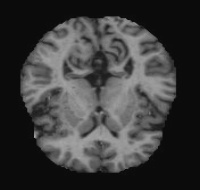

In [ ]:
import io

# load some sample images into memory
images = pq.read_table("mri.parquet", columns=["img_data"])["img_data"].chunks[0]
images = [Image.open(io.BytesIO(r.as_buffer())).convert("L") for r in images]
images = [np.array(x) for x in images]
images[0]

array([[ 9, 12, 15, ..., 13,  8, 13],
       [12, 10, 17, ...,  7, 14, 10],
       [10, 13, 41, ..., 10, 19,  7],
       ...,
       [11, 14, 14, ..., 12, 11, 12],
       [11, 11, 11, ..., 11, 11, 11],
       [13, 10, 11, ..., 11, 11, 10]], dtype=uint8)
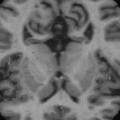

In [ ]:
# crop the stack of image array to exactly 120x120 in the center
def crop_center(img):
    h, w = img.shape[:2]

    start_row = (h - 120) // 2
    start_col = (w - 120) // 2

    return img[start_row:start_row + 120, start_col:start_col + 120]

crop_center(images[0])

array([[ 3,  8, 12, ...,  9,  1,  9],
       [ 8,  4, 16, ...,  0, 11,  4],
       [ 4,  9, 54, ...,  4, 19,  0],
       ...,
       [ 6, 11, 11, ...,  8,  6,  8],
       [ 6,  6,  6, ...,  6,  6,  6],
       [ 9,  4,  6, ...,  6,  6,  4]], dtype=uint8)
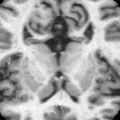

In [ ]:
# normalize the image so that the lowest value is 0 and the largest value is 255
# make sure your numpy dtype ends up being uint8 at the end!
def normalize(img):
  img = img.astype(float)

  min_val = img.min()
  max_val = img.max()

  img = (img - min_val) / (max_val - min_val) * 255

  return img.astype(np.uint8)

normalize(crop_center(images[0]))


In [ ]:
# PennGrader
img = Image.open("/content/alzheimers/MildDemented/00046ff7-0fae-4796-9a2b-2df47095bfe6.jpg").convert("L")
img = np.array(img)
img = normalize(crop_center(img))
img = img.flatten().tolist()
penngrader2.submit("hw4", "problem1_4", img)


Rate limited. Waiting 12s before retrying submission...
[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 5/5.


## 1.5 Writing the cleaned data

Next, we'll construct a new Parquet file with our cleaned up images. Instead of storing the JPG binary data, we'll store the 120*120 = 14400 brightness values as a fixed size list.

To do this transformation reasonably, you must write out the new Parquet *while you are reading the current one*! Call the new Parquet file `cleaned_mri.parquet`.

In [ ]:

img_array_type = pa.list_(pa.uint8(), list_size=14400)
schema = pa.schema([
    pa.field("img_path", pa.string()),
    pa.field("img_class", pa.string()),
    pa.field("img_class_numeric", pa.uint8()),
    pa.field("img_data", pa.binary()),
    pa.field("img_array", img_array_type)
])

pf = pq.ParquetFile("mri.parquet")

# TODO

import io
import numpy as np
from PIL import Image

with pq.ParquetWriter("cleaned_mri.parquet", schema) as writer:
  for batch in pf.iter_batches(batch_size=64):
    batch_dict = batch.to_pydict()

    cleaned_arrays = []

    for raw_bytes in batch_dict["img_data"]:
      img = Image.open(io.BytesIO(raw_bytes)).convert("L")
      img = np.array(img)

      cropped = crop_center(img)
      normalized = normalize(cropped)

      cleaned_arrays.append(normalized.flatten().tolist())

    table = pa.Table.from_pydict(
        {
            "img_path": batch_dict["img_path"],
            "img_class": batch_dict["img_class"],
            "img_class_numeric": batch_dict["img_class_numeric"],
            "img_data": batch_dict["img_data"],
            "img_array": cleaned_arrays
        },
        schema=schema
    )

    writer.write_table(table)

print("Finished writing cleaned_mri.parquet")

Finished writing cleaned_mri.parquet


In [ ]:
df = pq.read_table("cleaned_mri.parquet", columns=["img_class", "img_class_numeric"]).to_pandas()
icc = df["img_class"].value_counts().to_json()
icnc = df["img_class_numeric"].value_counts().to_json()
penngrader2.submit("hw4", "problem1_5", {"icc": icc, "icnc": icnc})

[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 5/5.


# Part 2: Image analysis and feature extraction

Now that we have our image dataset created, let's analyze our images a bit and extract features from them. Then, we'll use those extracted features to build a classifier.

Later, we'll use convolutional neural networks to automatically engineer features for us.

# 2.1: Incremental PCA over MRIs (5 points)

We'll start by applying [principal component analysis](https://scikit-learn.org/stable/modules/decomposition.html#pca) to our image data. This will help us identify the key components of dataset, such that each image can be represented as a mixture of those components.

Our dataset is too large to use the usual PCA algorithm. There's two alternative ways for us to compute PCA: incremental PCA and sampling. First, we'll use [incremental PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.IncrementalPCA.html) to handle our dataset.

Using an `IncrementalPCA` with 10 components called `pca`, use the `partial_fit` function to train on batches of 256 images at a time. Do not load the entire dataset into memory -- build these batchs in a streaming fashion from the Parquet file using the [`iter_batches`](https://arrow.apache.org/docs/python/generated/pyarrow.parquet.ParquetFile.html?utm_source=chatgpt.com#pyarrow.parquet.ParquetFile.iter_batches) function. Make sure to only read the `img_array` column.

This will take a while to run (multiple minutes). Try to avoid converting data into Python lists when possible -- `np.vstack` might be helpful.

In [ ]:
from sklearn.decomposition import IncrementalPCA
import pyarrow.parquet as pq
import numpy as np

pca = IncrementalPCA(n_components=10)

pf = pq.ParquetFile("cleaned_mri.parquet")

for i, batch in enumerate(pf.iter_batches(batch_size=256, columns=["img_array"])):
    img_arrays = batch.column("img_array").to_numpy(zero_copy_only=False)
    X_batch = np.vstack(img_arrays).astype(np.float32) / 255.0

    pca.partial_fit(X_batch)

    if i % 10 == 0:
        print(f"Finished batch {i}")

print("Finished fitting IncrementalPCA")


Finished batch 0
Finished batch 10
Finished batch 20
Finished batch 30
Finished batch 40
Finished batch 50
Finished batch 60
Finished batch 70
Finished batch 80
Finished batch 90
Finished batch 100
Finished batch 110
Finished batch 120
Finished batch 130
Finished fitting IncrementalPCA


In [ ]:
penngrader2.submit("hw4", "problem2_1", {"ns": int(pca.n_samples_seen_), "cs": pca.components_.shape})

[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 5/5.


We can visualize the components we just found, which can be viewed as the components that make up each of our scans:

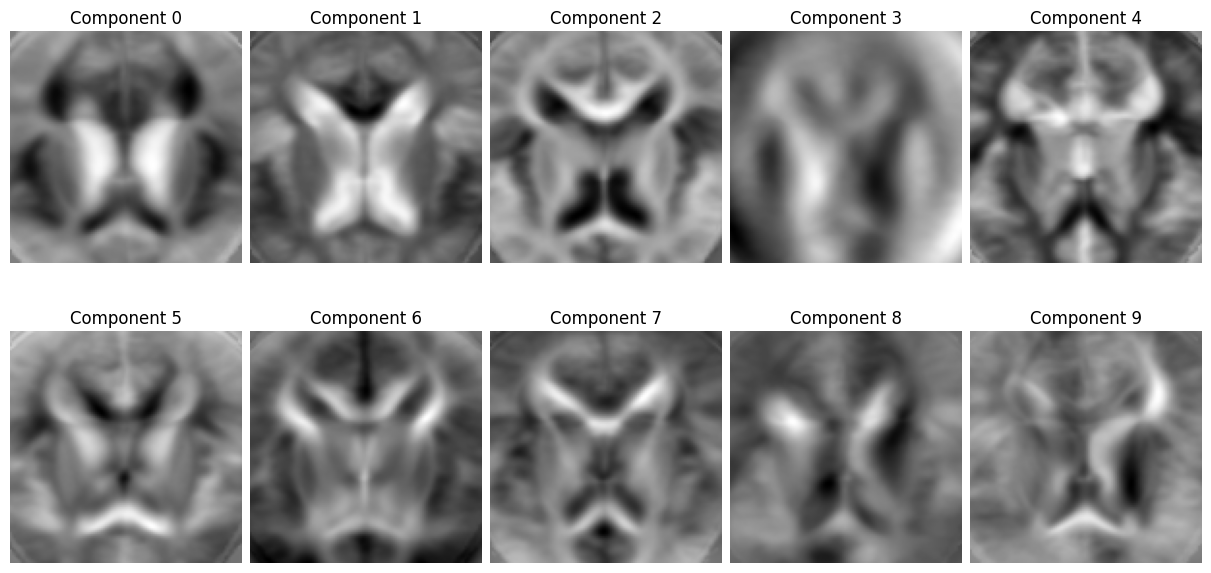

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6), constrained_layout=True)
axes = axes.flatten()

for idx, (ax, comp) in enumerate(zip(axes, pca.components_)):
  comp = comp.reshape(120, 120)
  ax.imshow(comp, cmap="gray")
  ax.axis("off")
  ax.set_title(f"Component {idx}")


... and we can view any particular brain scan as a mixture of these components (i.e., a linear combination of the principal components)! Below, an example brain scan ("Original") is mapped into our component space, then reconstructed. The original and reconstructed images are plotted. The printed array of coefficients can be used as a feature representation of our images!

Coefs: [[-1.41736461e+03  1.58025579e+04  1.08787873e+04  7.37499931e+00
  -4.36401554e+03  7.79875401e+02 -2.38274849e+03 -9.85997259e+02
   3.48911369e+02  8.09894561e+02]]


Text(0.5, 1.0, 'Reconstructed')

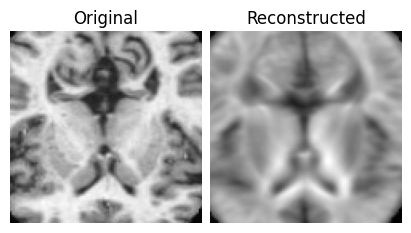

In [ ]:
pf = pq.ParquetFile("cleaned_mri.parquet")
img = next(pf.iter_batches(batch_size=1, columns=["img_array"]))
ex_brain = img["img_array"].to_numpy(zero_copy_only=False)[0]

as_mixture = pca.transform([ex_brain])
ex_brain = ex_brain.reshape(120, 120)
print("Coefs:", as_mixture)

reconstructed = pca.inverse_transform(as_mixture)
reconstructed = reconstructed.reshape(120, 120)

fig, axes = plt.subplots(1, 2, figsize=(4, 3), constrained_layout=True)
axes[0].imshow(ex_brain, cmap="gray")
axes[0].axis("off")
axes[0].set_title("Original")
axes[1].imshow(reconstructed, cmap="gray")
axes[1].axis("off")
axes[1].set_title("Reconstructed")

# 2.2: PCA over MRI Samples (5 points)

Doing incremental PCA was kind of a pain, and was a little slow. What if we just sampled some random scans from our dataset and did regular PCA?

After using DuckDB to sample 1000 rows from the Parquet file, use regular PCA to component 10 components of the sample. Name the PCA transformer `sample_pca`.

In [ ]:
# sample 1000 scans with duckdb
query = """
select img_array from read_parquet('cleaned_mri.parquet') using sample 1000
"""
samples = duckdb.sql(query).fetchnumpy()["img_array"]
samples = np.vstack(samples)
samples.shape


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(1000, 14400)

In [ ]:
# TODO: use PCA to component 10 principal components of `samples`
from sklearn.decomposition import PCA

sample_pca = PCA(n_components=10)
sample_pca.fit(samples)


PCA(n_components=10)

In [ ]:
penngrader2.submit("hw4", "problem2_2", {"ns": int(sample_pca.n_samples_), "cs": sample_pca.components_.shape})

[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 5/5.


We can once again see our components:

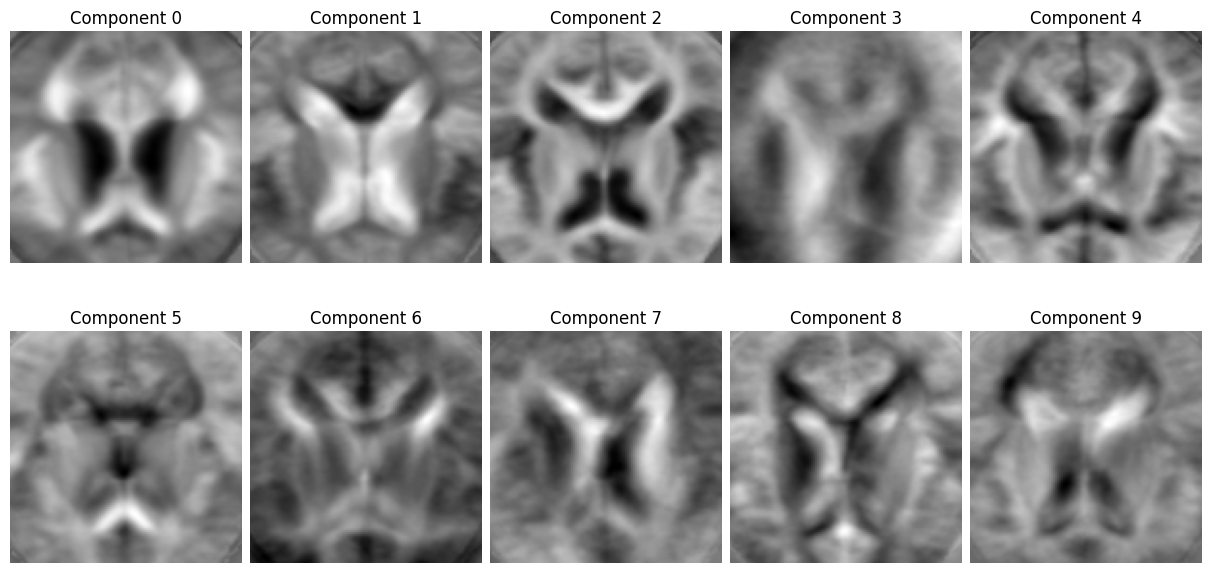

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6), constrained_layout=True)
axes = axes.flatten()

for idx, (ax, comp) in enumerate(zip(axes, sample_pca.components_)):
  comp = comp.reshape(120, 120)
  ax.imshow(comp, cmap="gray")
  ax.axis("off")
  ax.set_title(f"Component {idx}")


# 2.3 Comparing the transformations (10 points)

Now we have an incremental PCA over the full dataset (`pca`) and a regular PCA computed over samples (`sample_pca`). Let's see which one is better!

A good proxy metric for how good the components are is to look at the reconstruction error across the entire dataset. Using mean squared error, compute the reconstruction error of both transformations. To do this, iterate over batches of size 1024 from the Parquet file. Print the the final loss of both transformations.

In [ ]:
from sklearn.metrics import mean_squared_error
import pyarrow.parquet as pq
import numpy as np

pca_err_total = 0.0
sample_pca_err_total = 0.0
n_rows_total = 0

pf = pq.ParquetFile("cleaned_mri.parquet")

for batch in pf.iter_batches(batch_size=1024, columns=["img_array"]):
    img_arrays = batch.column("img_array").to_numpy(zero_copy_only=False)
    X = np.vstack(img_arrays).astype(np.float32) / 255.0

    X_pca_recon = pca.inverse_transform(pca.transform(X))
    X_sample_recon = sample_pca.inverse_transform(sample_pca.transform(X))

    batch_n = X.shape[0]

    pca_err_total += mean_squared_error(X, X_pca_recon) * batch_n
    sample_pca_err_total += mean_squared_error(X, X_sample_recon) * batch_n
    n_rows_total += batch_n

pca_err_total /= n_rows_total
sample_pca_err_total /= n_rows_total

print("Incremental PCA error:", pca_err_total)
print("Sample PCA error:", sample_pca_err_total)

Incremental PCA error: 0.03201049681398861
Sample PCA error: 995.6828053670487


In [ ]:
# WARNING: YOU MUST RUN THIS CELL IMMEDIATELY AFTER RUNNING THE CELL ABOVE. If
# you run some cell in between, you will get a nonsense grade.

src = In[len(In) - 2]
penngrader2.submit("hw4", "problem2_3", src)

[queued] Queued for grading (position 1)
[started] Grading started
[progress] Prepared grading assistant call
[progress] Grading assitant response is parsed
[succeeded] Grading completed
✅ Correct. Score: 10/10. 



You should see that the new techniques create nearly identical reconstruction accuracy. Sometimes, simplicity wins! Going forward, you can use either technique.

# Part 3: Training a logistic regression model

Now that we have experience featurizing images, it is time to train a logistic regression model to predict dementia status from MRI scans. To do this, we must carefully divide our data into training and testing sets, and ensure that all training -- including fitting PCA -- only happens on the training set.

## 3.1 Creating train/test split (5 points)

`scikit-learn` has a lot of helper functions for generating training / testing splits, but many of these assume that the entire dataset can fit in memory. We will be assuming that our dataset is too large to fit in memory.

Let's do a train/test split using DuckDB. Create a new table called `data` by reading the Parquet file and then adding a new, boolean column called `train` that is true 80% of the time and false otherwise (randomly).

In [ ]:
con = duckdb.connect("data.duckdb")
con.sql("""
CREATE OR REPLACE TABLE data AS
SELECT
  *,
  random() < 0.8 AS train
FROM read_parquet('cleaned_mri.parquet')
""")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
ts = con.sql("select count(*) from data where train").fetchone()[0]
penngrader2.submit("hw4", "problem3_1", {"ts": ts})

[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 5/5.


## 3.2 Fitting PCA on the training data (5 points)

Next, let's fit PCA on our training data. Do this by sampling 1000 rows from your training set using DuckDB, then fitting a PCA transformer called `train_pca`. You should do the sampling in DuckDB -- look up a good way to do this. Keep the order of operations in mind!

In [ ]:
# TODO
from sklearn.decomposition import PCA
import duckdb
import numpy as np

query = """
SELECT img_array
FROM (
  SELECT *
  FROM data
  WHERE train = TRUE
) t
USING SAMPLE 1000 ROWS
"""

samples = con.sql(query).fetchnumpy()["img_array"]
samples = np.vstack(samples)

train_pca = PCA(n_components=10)
train_pca.fit(samples)

print(samples.shape)

(1000, 14400)


In [ ]:
penngrader2.submit("hw4", "problem3_2", {"ns": int(train_pca.n_samples_), "cs": train_pca.components_.shape})

[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 5/5.


## 3.3 Materializing the training data

Now that we have our feature extractor, we can build the feature representation for each of our images. While we should still avoid reading every image into memory at once, we can assume that all image's feature representation (10 values) can fit into memory.

Using DuckDB, stream the training data into memory, collecting the feature representation of each image into an array called `train_X`, and each image's numeric label into an array called `train_y`.

Stream batches of 1024 rows from DuckDB. To do this, you can use `con.execute("...")` to get a cursor, then `cursor.fetch_record_batch(1024)` to iterate over batches.

Once `train_X` and `train_y` have been created, use a `StandardScaler` to standardize your data input features (this is expected by scikit learn's logistic regression). Save the scalar as `train_scale`.

In [ ]:
from sklearn.preprocessing import StandardScaler

# TODO


reader = con.execute("""
    SELECT img_array, img_class_numeric
    FROM data
    WHERE train = TRUE
""").fetch_record_batch(1024)

X_batches = []
y_batches = []

for batch in reader:
  batch_imgs = np.vstack(batch.column(0).to_pylist()).astype(np.float32)
  batch_y = np.array(batch.column(1).to_pylist(), dtype=np.uint8)

  batch_X = train_pca.transform(batch_imgs)

  X_batches.append(batch_X)
  y_batches.append(batch_y)

train_X = np.vstack(X_batches)
train_y = np.concatenate(y_batches)

train_scale = StandardScaler()
train_X = train_scale.fit_transform(train_X)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
penngrader2.submit("hw4", "problem3_3", {"x": train_X.shape, "y": train_y.shape})

[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 5/5.


## 3.4 Training a logistic regression model (5 points)

Next, we'll use our training data to train a logistic regression model on our data.

Use scikit-learn's `LogisticRegression`, and name the model object `reg`.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# TODO
reg = LogisticRegression(max_iter=1000)
reg.fit(train_X, train_y)

LogisticRegression(max_iter=1000)

In [ ]:
penngrader2.submit("hw4", "problem3_4", {"c": reg.classes_.tolist(), "f": reg.n_features_in_})

Rate limited. Waiting 11s before retrying submission...
[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 5/5.


## 3.5 Using the logistic regression model (5 points)

To evaluate the logisitic regression model, we need to predict classes for our test data. Note that, when evaluating the test data, we have to only use information from the training set -- including our PCA.

First, get the list of test images and labels with DuckDB. Then, transform the images with our PCA transformer. Finally, use `reg` to predict the class of each test image. Save the predictions as `pred_y`.

In [ ]:
# TODO
test_query = """
    SELECT img_array, img_class_numeric
    FROM data
    WHERE train = FALSE
"""

test_result = con.sql(test_query).fetchnumpy()

test_imgs = np.vstack(test_result["img_array"]).astype(np.float32)
test_y = np.array(test_result["img_class_numeric"], dtype=np.uint8)

test_X = train_pca.transform(test_imgs)
test_X = train_scale.transform(test_X)

pred_y = reg.predict(test_X)

In [ ]:
penngrader2.submit("hw4", "problem3_5",
 {"shape": pred_y.shape, "min": int(np.min(pred_y)), "max": int(np.max(pred_y))})

[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 5/5.


## 3.6 Computing metrics for logistic regression

Let's see how well our model did! Let's measure the accuracy and plot the confusion matrix for our predictor.

For **accuracy**, print out the model's accuracy on the test set along with what the accuracy of predicting the most common class would be (the prior).

For the **confusion matrix**, compute and plot the confusion matrix.

You can use the appropiate functions in `sklearn.metrics` for this.

Model accuracy: 0.4054211600116584
Prior accuracy: 0.277615855435733
[[1219  232  385   69]
 [ 762  286  587  133]
 [ 447  276  968  167]
 [ 278  181  563  309]]


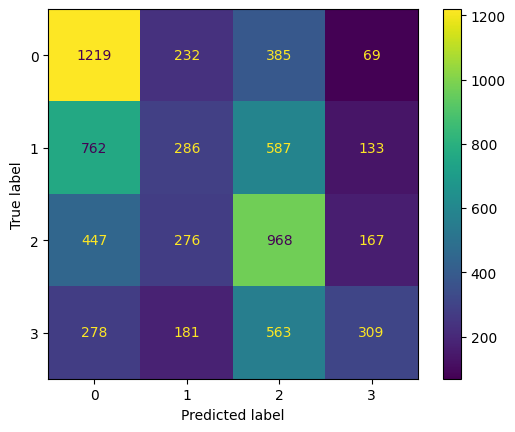

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

acc = accuracy_score(test_y, pred_y)
print("Model accuracy:", acc)

most_common_class = np.bincount(test_y).argmax()
prior_pred = np.full_like(test_y, most_common_class)
prior_acc = accuracy_score(test_y, prior_pred)
print("Prior accuracy:", prior_acc)

cm = confusion_matrix(test_y, pred_y)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [ ]:
# WARNING: YOU MUST RUN THIS CELL IMMEDIATELY AFTER RUNNING THE CELL ABOVE. If
# you run some cell in between, you will get a nonsense grade.

src = In[len(In) - 2]
penngrader2.submit("hw4", "problem3_6", src)

Rate limited. Waiting 10s before retrying submission...
[queued] Queued for grading (position 1)
[started] Grading started
[progress] Prepared grading assistant call
[progress] Grading assitant response is parsed
[succeeded] Grading completed
✅ Correct. Score: 5/5. 



## 3.7 Random forest training & evaluation

Let's try a `RandomForestClassifier` instead of the logistic regression model. Like before, create a model, train it on the scaled data, and evaluate the accuracy and plot the confusion matrix.

Save the random forest classifier to a variable named `clf`.

You can use the default hyperparameters for the random forest for now.

Random forest accuracy: 0.6995045176333431
[[1411  231  205   58]
 [ 311 1036  340   81]
 [ 129  207 1364  158]
 [  55   87  200  989]]


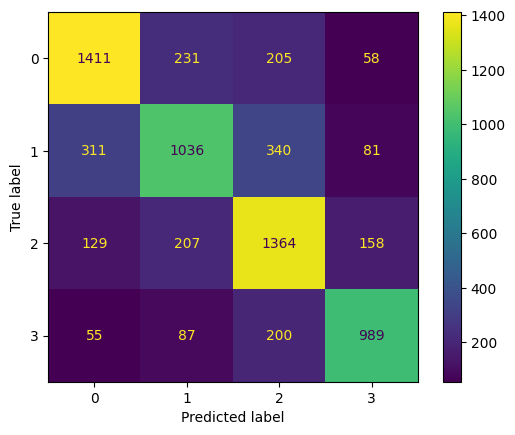

In [ ]:
from sklearn.ensemble import RandomForestClassifier
# TODO
clf = RandomForestClassifier()
clf.fit(train_X, train_y)

rf_pred_y = clf.predict(test_X)
rf_acc = accuracy_score(test_y, rf_pred_y)
print("Random forest accuracy:", rf_acc)

rf_cm = confusion_matrix(test_y, rf_pred_y)
print(rf_cm)

disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm)
disp.plot()
plt.show()

In [ ]:
penngrader2.submit("hw4", "problem3_7", {"cn": len(clf.classes_), "nf": clf.n_features_in_})

[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 5/5.


## 3.8 Hyperparameter tuning with CV (5 points)

Next, let's tune our random forest model with `GridSearchCV`. The grid searcher will use cross validation on our training data in order to estimate which hyperparameters are best. It is critical that `GridSearchCV` never sees our test data!

Use `GridSearchCV` to try the following hyperparameter grid, maximizing accuracy:

* `n_estimators = [50, 100, 150]`
* `max_depth = [13, 15, 17]`

Save your `GridSearchCV` instance to a variable named `search`.

The grid search might take a while -- to watch progress, you can pass `verbose=4` to the `GridSearchCV` constructor. The search will take several minutes. In practice, you'd search a much larger space using a more powerful machine that would let you parallelize the search.

Print out the `search.best_params_` and `search.best_score_` values.

In [ ]:
from sklearn.model_selection import GridSearchCV

# TODO
param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [13, 15, 17]
}

search = GridSearchCV(
    estimator=RandomForestClassifier(),
    param_grid=param_grid,
    scoring="accuracy",
    verbose=4
)

search.fit(train_X, train_y)

print(search.best_params_)
print(search.best_score_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV 1/5] END .....max_depth=13, n_estimators=50;, score=0.642 total time=   6.1s
[CV 2/5] END .....max_depth=13, n_estimators=50;, score=0.632 total time=   5.2s
[CV 3/5] END .....max_depth=13, n_estimators=50;, score=0.634 total time=   5.7s
[CV 4/5] END .....max_depth=13, n_estimators=50;, score=0.630 total time=   5.8s
[CV 5/5] END .....max_depth=13, n_estimators=50;, score=0.649 total time=   5.4s
[CV 1/5] END ....max_depth=13, n_estimators=100;, score=0.643 total time=  11.4s
[CV 2/5] END ....max_depth=13, n_estimators=100;, score=0.644 total time=  11.4s
[CV 3/5] END ....max_depth=13, n_estimators=100;, score=0.646 total time=  11.4s
[CV 4/5] END ....max_depth=13, n_estimators=100;, score=0.633 total time=  11.3s
[CV 5/5] END ....max_depth=13, n_estimators=100;, score=0.655 total time=  11.7s
[CV 1/5] END ....max_depth=13, n_estimators=150;, score=0.642 total time=  16.9s
[CV 2/5] END ....max_depth=13, n_estimators=150;,

In [ ]:
penngrader2.submit("hw4", "problem3_8", {"bp": search.best_params_, "mft": search.cv_results_["mean_fit_time"].tolist()})

[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 5/5.


For the final random forest model, train a model using the hyperparameters we found via the grid search on the entire training data, then evaluate on the test data. How does the random forest compare to logistic regression?

Final random forest accuracy: 0.6868259982512387
Logistic regression accuracy: 0.4054211600116584


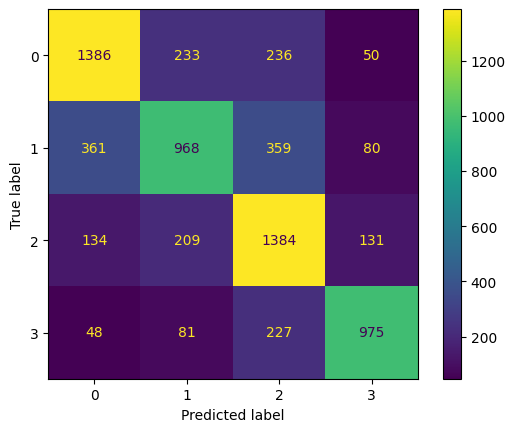

In [ ]:
# TODO
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_params = search.best_params_

final_clf = RandomForestClassifier(
    n_estimators = best_params["n_estimators"],
    max_depth = best_params["max_depth"]
)

final_clf.fit(train_X, train_y)

final_pred_y = final_clf.predict(test_X)
final_acc = accuracy_score(test_y, final_pred_y)

print("Final random forest accuracy:", final_acc)
print("Logistic regression accuracy:", accuracy_score(test_y, pred_y))

cm = confusion_matrix(test_y, final_pred_y)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

# Part 4: CNNs

Next, we'll train a convolutional neural network to predict dementia levels from our dataset. Instead of using the PCA features, we'll use the images directly, and let the neural network handle the feature engineering for us!

Training neural networks is very slow, and benefits from special hardware. If you'd like, you can switch your Colab runtime to the "T4" or other TPU/GPU type and use that accelerator with PyTorch.

**Dataset** The first thing we need in order to train a neural network with PyTorch is to create a `Dataset` that looks like a normal Python array. In general, datasets neeed to deal with loading and fetching specific data items. For simplicity, we'll load everything into memory now, since more advanced techniques for training are beyond the scope of this course.

In [ ]:
con = duckdb.connect("data.duckdb")
from torch.utils.data import Dataset, DataLoader
class AlzheimerDataset(Dataset):
  def __init__(self, df):
    self.df = df

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    image = self.df["img_array"][idx]
    image = (image.astype(np.float32) / 255.0).reshape(120, 120)
    label = self.df["img_class_numeric"][idx]
    return (image, label)

train_data = con.sql("select img_class_numeric, img_array from data where train").to_df()
test_data = con.sql("select img_class_numeric, img_array from data where not train").to_df()

train_data = AlzheimerDataset(train_data)
test_data = AlzheimerDataset(test_data)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**Model** We'll use a simple feed-forward convolution model. Note the presense of normalization layers, activation functions, and pooling. In general, the entire network architecture is considered a hyperparameter, and needs to be tuned! Since training can take a long time, we'll just train this one model.

In [ ]:
from torch import nn
from tqdm import tqdm

class OurCNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
      nn.Conv2d(1, 16, 3),
      nn.BatchNorm2d(16),
      nn.ReLU(),
      nn.MaxPool2d(3),
      nn.Conv2d(16, 8, 3),
      nn.BatchNorm2d(8),
      nn.ReLU(),
      nn.MaxPool2d(3),
      nn.Flatten(),
      nn.Linear(1152, 4)
    )

  def forward(self, x):
    x = x.unsqueeze(1)
    return self.layers(x)

## 4.1 CNN Training (10 points)

Next, we train the CNN. Fill out the missing parts of the training code below. Then run the training process!

In [ ]:
import torch
train_dl = DataLoader(train_data, batch_size=32, shuffle=True)

net = OurCNN()
opt = torch.optim.Adam(net.parameters())
loss_fn = nn.CrossEntropyLoss()

running_loss = []
for epoch in range(10):
  print("Starting epoch", epoch)
  for img_batch, label_batch in tqdm(train_dl):
    # TODO: zero the current gradients via the optimizer
    opt.zero_grad()
    # TODO: compute the loss, save as `loss`
    logits = net(img_batch)
    loss = loss_fn(logits, label_batch)

    running_loss.append(loss.item())
    # TODO: run the backward pass by calling .backward() on the loss
    loss.backward()
    # TODO: take an optimization step based on the gradients
    opt.step()

Starting epoch 0


100%|██████████| 848/848 [03:01<00:00,  4.67it/s]


Starting epoch 1


100%|██████████| 848/848 [03:10<00:00,  4.44it/s]


Starting epoch 2


...

100%|██████████| 848/848 [03:10<00:00,  4.44it/s]


Starting epoch 8


100%|██████████| 848/848 [03:09<00:00,  4.47it/s]


Starting epoch 9


100%|██████████| 848/848 [03:10<00:00,  4.44it/s]


In [ ]:
penngrader2.submit("hw4", "problem4_1", running_loss)

[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 10/10.


## 4.2 Measure accuracy (5 points)

Now that we've trained our model for 10 epochs, let's measure the model's accuracy. Complete the code below.

You might find `torch.no_grad()` helpful!

In [ ]:
test_dl = DataLoader(test_data, batch_size=32, shuffle=True)

# TODO

net.eval()
correct = 0
total = 0

with torch.no_grad():
  for img_batch, label_batch in test_dl:
    logits = net(img_batch)
    preds = torch.argmax(logits, dim=1)
    correct += (preds == label_batch).sum().item()
    total += label_batch.shape[0]

print("Accuracy:", correct/total)

Accuracy: 0.8137569221801224


In [ ]:
penngrader2.submit("hw4", "problem4_2", {"correct": correct, "total": total})

[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 5/5.


# Submit

That's all! Please download both the `homework4.ipynb` and `homework4.py` versions of your notebook and submit them to Gradescope. Make sure your student ID was correctly set at the top of the notebook.